This notebook runs through elements of the optimized first wedge and the QQ+Sector Dipole dispersion suppressor.

Written by: Inci Karaaslan

Created: 2/22/2026 Updated: 4/19/2026

# Setup

In [1]:
# Important! All of the functions utilized in this notebook unless defined here comes from these two scripts. 
# For more information on the functions, check scan.py and g4beam.py!!
from scan import *
from g4beam import *
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
import numpy as np
import pandas as pd
from tqdm import *
import pickle
import itertools
from tabulate import tabulate
import re

In [2]:
# Make Sure g4bl path is in here -- change the "/home/incik/G4beamline-3.08/bin" with your "G4beamline-3.08/bin" path
import os
os.environ["PATH"] += os.pathsep + "/home/incik/G4beamline-3.08/bin"
import shutil
print(shutil.which("g4bl"))

/home/incik/G4beamline-3.08/bin/g4bl


# Initial distribution

First Wedge Optimization done by Daniel Fu: A Gaussian beam is generated using Mike Syphers' theoretical description of the parameters needed via https://nicadd.niu.edu/~syphers/tutorials/analyzeTrack.html#analyzing-a-distribution.

The parameters of the initial beam are treated as constants, but some things are known about their effects:
- **Transverse emittance**: Should be as low as possible. For this test we use an "optimistic" value of 110 microns.
- **Momentum**: Decreasing this appears to slightly decreases x-emittance.
- **Beta**: Decreasing this decreases the y-emittance growth. There may also be an optimal value for x-emittance.
- **Alpha**: Increasing this decreases the y-emittance growth, but past a certain point increases the x-emittance. I believe 0.7 focuses the beam onto the wedge center with a VD distance of 24 mm.
- **Longitudinal emittance**: Effects not yet tested.
- **Standard deviation of momentum**: Decreasing this decreases the x-emittance.
- **Virtual detector distance**: Almost irrelevant. Should be more than 3x the length of the wedge to ensure accurate measurements.

In [3]:
t_emit = 0.145  # mm
momentum = 100  # MeV/c
beta = 0.03    # m
alpha = 0.7     # dimensionless
l_emit = 1      # mm
pz_std = 1    # MeV/c
vd_dist = 24    # mm

pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=20000)
pre_w1["PDGid"] = -13
print_all_params(pre_w1)

-----------------------------
Twiss parameters for X
emit  = 0.14325674964188387 mm
beta  = 0.03002080423843618 m
gamma = 48.94409466387622 1/m
alpha = 0.6850847279948056
D     = -0.0025521514236664954 m
D'    = 0.05755853812362322

Twiss parameters for Y
emit  = 0.14394280955936822 mm
beta  = 0.0301682285962223 m
gamma = 49.96814162481579 1/m
alpha = 0.7123554724053531
D     = 1.1399135828634968e-05 m
D'    = -0.028343411864421755

Z-emittance:  1.2747027692860182 mm
Z std: 155.8168456829875 mm
p std: 1.006268003089023 MeV/c
Mean momentum: 100.00082350474081 MeV/c
-----------------------------


In [4]:
write_trackfile(pre_w1, "particles_before.txt")

# First wedge -- Run Optimized Value

In [14]:
# Write the wedge output into a file
post_w1 =  run_g4beam(pre_w1, "G4_FinalCooling_auto.g4bl")
post_w1 = cut_outliers(post_w1)
print_all_params(post_w1)
write_trackfile(post_w1, "particles_after_w1.txt")

-----------------------------
Twiss parameters for X
emit  = 0.042401335603664346 mm
beta  = 0.03508893122494888 m
gamma = 197.8653582329746 1/m
alpha = -2.4378030984549834
D     = 0.019895726074885843 m
D'    = -0.04016154805565274

Twiss parameters for Y
emit  = 0.14677535908486777 mm
beta  = 0.025131369938303724 m
gamma = 58.28197806073687 1/m
alpha = -0.6816934438444303
D     = -0.00020427203081759302 m
D'    = -0.012889415546223268

Z-emittance:  6.348793058641248 mm
Z std: 144.19614561701746 mm
p std: 7.1526917343747325 MeV/c
Mean momentum: 87.33722064065456 MeV/c
-----------------------------


In [15]:
# Optimized G4_FinalCooling_auto.g4bl parameters
w1_length = 7.51 #mm
w1_angle = 47.3 #deg
offset = w1_length / (math.tan(w1_angle * math.pi / 180) * 2)
base_length = 24
abswidth = 100
parameters = dict(
        abshalfangle3=str(w1_angle),
        absoffset3=str(offset),
        abshgt=str(offset * base_length / w1_length + 0.1),
        absLEN3=str(base_length)
    )
L_centerline = float(parameters['absLEN3']) + 1
print("Where to put the next element: " + str(L_centerline) + "mm")
print(parameters)

Where to put the next element: 25.0mm
{'abshalfangle3': '47.3', 'absoffset3': '3.465014271263713', 'abshgt': '11.173281292986566', 'absLEN3': '24'}


In [16]:
# If particles_after isn't updated with Z = 0, so if we want to use the resulting distribution as the initial distribution
# for each of the files, we must set the particle distribution we get after to have a z of 0.
def convertZ(input_file, output_file, set_to=0):
    event_id_counter = 1
    with open(input_file, "r") as infile, open(output_file, "w") as outfile:
        for line in infile:
            # Skip header lines (those starting with #)
            if line.strip().startswith("#"):
                outfile.write(line)
                continue

            # Split the line into columns
            parts = line.strip().split()
            if len(parts) >= 12:
                parts[2] = str(set_to)  # Set the 3rd column (z) to 0
                # Replace event ID (assuming it's the 9th column, zero-based index 8)
                # Adjust if your event ID is in a different column
                parts[8] = str(event_id_counter)
                event_id_counter += 1
                new_line = " ".join(parts)
                outfile.write(new_line + "\n")
            else:
                # Handle lines that don't match expected format
                outfile.write(line)
    print(f"Updated file saved as '{output_file}'")
    os.remove(input_file)
    return None

In [17]:
convertZ("particles_after_w1.txt", "particles_after_w1upt.txt", set_to=0.0)

Updated file saved as 'particles_after_w1upt.txt'


In [18]:
post_w1_zero = read_trackfile("particles_after_w1upt.txt")

# Dispersion correction optimized

The main goal is to have $D_x \approx 0$ up to 1e-5 m while keeping $\beta_x$ relatively periodic and about at the same value.

In [19]:
# Write values to the prepared G4BL template
def write_input_from_template(template_path, replacements, out_path):
    with open(template_path, 'r') as f:
        txt = f.read()
    try:
        txt = txt.format(**replacements)
    except KeyError as e:
        raise RuntimeError(f"Template substitution failed; missing placeholder: {e}")
    with open(out_path, 'w') as f:
        f.write(txt)

In [20]:
def clean_field_files():
    for f in ["field_cellBSec.dat", "field_cellQ2.dat"]:
        if os.path.exists(f):
            os.remove(f)

In [21]:
# Beta and Dispersion we have from after the wedge:
x0_params, y0_params, _ = calc_all_params(post_w1)
beta_x_ref= x0_params[1]; beta_y_ref= y0_params[1]
print(r"$\beta_x$: " + str(beta_x_ref), r"$\beta_y$: " + str(beta_y_ref))
print("D_x: " + str(x0_params[4]), "D_y: " + str(y0_params[4]))
print("Emittance: " + str(x0_params[0]))

$\beta_x$: 0.03508893122494888 $\beta_y$: 0.025131369938303724
D_x: 0.019895726074885843 D_y: -0.00020427203081759302
Emittance: 0.042401335603664346


In [22]:
def beam_size(beta, eps, n_sigma=15):
    """
    Compute full beam width/height in mm for given beta (m) and emittance (mm·mrad)
    """
    sigma = np.sqrt(beta * eps * 1e3)  # convert sigma (mm) = sqrt(m * 1e3 * mm)
    return n_sigma * sigma

# Consider max displacement to determine radius of the quads should be:
radius_q = max(
    np.percentile(np.abs(post_w1["x"]), 99.9),
    np.percentile(np.abs(post_w1["y"]), 99.9)
    ) * 10.0
print(f"x_max={np.percentile(np.abs(post_w1["x"]), 99.9):.1f} mm, y_max={np.percentile(np.abs(post_w1["y"]), 99.9):.1f} mm, radius_q={radius_q:.1f} mm")

B_pole_max = 5.0
gradBound = B_pole_max / (radius_q*1e-3)
print(f"Max gradient bound for quads : ({-gradBound}, {gradBound}) ")

x_max=7.3 mm, y_max=7.4 mm, radius_q=73.5 mm
Max gradient bound for quads : (-68.024380607369, 68.024380607369) 


In [23]:
def run_two_quadrupoles(df, Q1_gradient, Q2_gradient, Drift1_length, Q1_z, Q1_radius=radius_q, Q2_radius=radius_q, Q1_length=100, Q2_length=100, thickness=5):
    """
    Runs G4BL with two sequential quadrupoles.
    """
    Drift1_width=2*max(Q1_radius,Q2_radius)
    Drift1_height=2*max(Q1_radius,Q2_radius)
    # Q1_z : f"{L_centerline + (Q1_length / 2):.12f}",
    params = {
    "Q1_z": f"{Q1_z + (Q1_length / 2):.12f}",
    "Q1_length": f"{Q1_length:.12f}",
    "Q1_gradient": f"{Q1_gradient:.12f}",
    "radius_q1": f"{Q1_radius:.12f}",
    "radius_q2": f"{Q2_radius:.12f}",
    "thickness": f"{thickness:.12f}",
    "Q1_end": f"{Q1_z + Q1_length:.12f}",
    "Q2_length":f"{Q2_length:.12f}",
    "Q2_gradient": f"{Q2_gradient:.12f}",
    "Drift1_length": f"{Drift1_length:.12f}",
    "Drift1_z": f"{Q1_z + Q1_length + (Drift1_length / 2):.12f}",
    "Drift1_width": f"{Drift1_width:.12f}", 
    "Drift1_height":f"{Drift1_height:.12f}",
    "D1_end": f"{Q1_z + Q1_length + Drift1_length:.12f}",
    "Q2_z": f"{Q1_z + Q1_length + Drift1_length + Q2_length/2:.12f}",
    "Q2_end": f"{Q1_z + Q1_length + Drift1_length + Q2_length:.12f}",
    }

    print("PARAMS PASSED TO TEMPLATE:")
    for k, v in params.items():
        print(k, "=", v)
    write_input_from_template("G4_FinalCooling_dispsup_Q2.g4bl", params, "G4_FinalCooling_dispsup_Q2_run.g4bl")
    
    # Run this file
    res = run_g4beam(df, "G4_FinalCooling_dispsup_Q2_run.g4bl")

    if res is None or len(res) < 10:
        print("G4BL run failed or empty. Check template and parameters.")
        return None
    return res

In [76]:
history = []

def optimize_qq_drift_safe(x, df, beta_x_ref, beta_y_ref, w_disp=1000, w_beta=10.0):
    """
    Optimizer wrapper for two-quadrupole system.
    Includes:
    - Survival-aware penalty
    - Full diagnostics with printout
    - Logging to global 'history'
    """
    q1_gradient, q2_gradient, d1_length, q1_z = x
    print("\nTRYING x =", x)

    try:
        # Simulate particle propagation through two quadrupoles
        result = run_two_quadrupoles(df, q1_gradient, q2_gradient, d1_length, q1_z)

        print(f"x range: {result['x'].min():.1f} to {result['x'].max():.1f} mm")
        print(f"y range: {result['y'].min():.1f} to {result['y'].max():.1f} mm")
        print(f"Pz range: {result['Pz'].min():.1f} to {result['Pz'].max():.1f} MeV/c")
        print(f"Input particles: {5000}, Output particles: {len(result)}")
    except Exception as e:
        print("EXCEPTION in run_two_quadrupoles:", e)
        return 1e6

    if result is None or len(result) == 0:
        print("No particles survived")
        return 1e6

    # Compute survival fraction
    N0 = 2000
    Ns = len(result)
    survival = Ns / N0
    print(f"Particles survived: {Ns}/{N0} → survival={survival:.3f}")

    if survival < 0.94:
        print(f"Survival too low, returning penalty")
        return 1e12 + 1e6 * (0.94 - survival)

    # Compute optics parameters
    try:
        x_params, y_params, _ = calc_all_params(result)
    except Exception as e:
        print("EXCEPTION in calc_all_params:", e)
        return 1e5

    Dx, Dxp = x_params[4], x_params[5]
    beta_x, beta_y = x_params[1], y_params[1]
    ex, ey = x_params[0], y_params[0]

    eps = 1e-4

    # Dispersion penalty
    disp_penalty = (np.abs(Dx) / 1e-4)**2 + 10 * (np.abs(Dxp) / 1e-2)**2
    
    beta_x_max=0.9
    beta_y_max=0.9
    # Beta function penalty
    beta_penalty = (max(0, beta_x - beta_x_max) / beta_x_max)**2 \
                + (max(0, beta_y - beta_y_max) / beta_y_max)**2

    # Log-scaled losses
    optics_loss = w_beta * np.log(beta_penalty**2 + eps)
    disp_loss = w_disp * np.log(disp_penalty + eps)

    # Total objective
    val = optics_loss + disp_loss

    print(f"OBJECTIVE = {val:.6f}, Dx={Dx:.6f}, Dxp={Dxp:.6f}, beta_penalty={beta_penalty:.6f}, emit={ex:.6f}")

    # Log to history
    history.append({
        "Q1_G": q1_gradient,
        "Q2_G": q2_gradient,
        "Drift1_L": d1_length,
        "Q1_z": q1_z,
        "Dx": Dx,
        "Dxp": Dxp,
        "beta_x": beta_x,
        "beta_y": beta_y,
        "emit": ex,
        "survival": survival,
        "objective": val
    })

    return val

In [77]:
# -----------------------------
# Optimization Setup
# -----------------------------
x0 = [-61.97363495,  69.06470063, 2.02317333, 25.0]  # Initial guess

bounds = [
    [-gradBound, gradBound],          # Q1_gradient
    [-gradBound, gradBound],          # Q2_gradient
    [10, 3000],                        # Drift1_length
    [L_centerline, L_centerline*100] # Q1_z position
]

# Step 1: Global search with Differential Evolution
print("\n=== STEP 1: GLOBAL SEARCH (Differential Evolution) ===")
def objective(x):
    return optimize_qq_drift_safe(x, post_w1, beta_x_ref, beta_y_ref)

"""
res_global = scipy.optimize.differential_evolution(
    objective,
    bounds,
    maxiter=50,
    popsize=15,
    polish=True,
    updating='deferred',
    workers=-1
)

print("\nGlobal optimum found:", res_global.x, "Objective:", res_global.fun)"""

# Step 2: Local refinement with Nelder-Mead
print("\n=== STEP 2: LOCAL REFINEMENT (Nelder-Mead) ===")
res_local = minimize(
    optimize_qq_drift_safe,
    x0, bounds=bounds,
    args=(post_w1, beta_x_ref, beta_y_ref),
    method="Nelder-Mead",
    options={"xatol":1e-4, "fatol":1e-6, "maxiter":500}
)

print("\nLocal refinement complete")
print("Optimal parameters:", res_local.x)
print("Objective value:", res_local.fun)


=== STEP 1: GLOBAL SEARCH (Differential Evolution) ===

=== STEP 2: LOCAL REFINEMENT (Nelder-Mead) ===
iter value

TRYING x = [-61.97363495  68.02438061  10.          25.        ]
PARAMS PASSED TO TEMPLATE:
Q1_z = 75.000000000000
Q1_length = 100.000000000000
Q1_gradient = -61.973634950000
radius_q1 = 73.503058100001
radius_q2 = 73.503058100001
thickness = 5.000000000000
Q1_end = 125.000000000000
Q2_length = 100.000000000000
Q2_gradient = 68.024380607369
Drift1_length = 10.000000000000
Drift1_z = 130.000000000000
Drift1_width = 147.006116200001
Drift1_height = 147.006116200001
D1_end = 135.000000000000
Q2_z = 185.000000000000
Q2_end = 235.000000000000


/home/incik/Cooling_4D/FinalCandidates/QQB/scan.py:98: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(func, start, callback=callback, **kwargs)


x range: -47.3 to 45.6 mm
y range: -38.6 to 37.2 mm
Pz range: 22.4 to 101.9 MeV/c
Input particles: 5000, Output particles: 1848
Particles survived: 1848/2000 → survival=0.924
Survival too low, returning penalty

TRYING x = [-65.0723167   68.02438061  10.          25.        ]
PARAMS PASSED TO TEMPLATE:
Q1_z = 75.000000000000
Q1_length = 100.000000000000
Q1_gradient = -65.072316697500
radius_q1 = 73.503058100001
radius_q2 = 73.503058100001
thickness = 5.000000000000
Q1_end = 125.000000000000
Q2_length = 100.000000000000
Q2_gradient = 68.024380607369
Drift1_length = 10.000000000000
Drift1_z = 130.000000000000
Drift1_width = 147.006116200001
Drift1_height = 147.006116200001
D1_end = 135.000000000000
Q2_z = 185.000000000000
Q2_end = 235.000000000000
x range: -49.0 to 47.4 mm
y range: -34.8 to 30.8 mm
Pz range: 19.7 to 101.9 MeV/c
Input particles: 5000, Output particles: 1834
Particles survived: 1834/2000 → survival=0.917
Survival too low, returning penalty

TRYING x = [-61.97363495  64.623

In [79]:
x = [-58.23241772,  70.43198252,   2.0444023,   25.54675181]
df_opt_q = run_two_quadrupoles(post_w1, Q1_gradient=x[0], Q2_gradient=x[1], Drift1_length=x[2], Q1_z=x[3])
print(df_opt_q)
write_trackfile(df_opt_q, "particles_after_q2.txt")

PARAMS PASSED TO TEMPLATE:
Q1_z = 75.546751810000
Q1_length = 100.000000000000
Q1_gradient = -58.232417720000
radius_q1 = 73.503058100001
radius_q2 = 73.503058100001
thickness = 5.000000000000
Q1_end = 125.546751810000
Q2_length = 100.000000000000
Q2_gradient = 70.431982520000
Drift1_length = 2.044402300000
Drift1_z = 126.568952960000
Drift1_width = 147.006116200001
Drift1_height = 147.006116200001
D1_end = 127.591154110000
Q2_z = 177.591154110000
Q2_end = 227.591154110000
              x         y        z         Px        Py       Pz         t  \
0    -22.214000   2.90081  227.591  34.936200   2.73652  77.3885  0.991299   
1    -38.014500 -10.81250  227.591  63.428900 -12.25250  62.4915  1.790020   
2     19.727800 -14.38720  227.591 -32.635700 -17.45810  71.9152  1.829960   
3    -23.800100 -14.53700  227.591  31.722600 -17.05680  87.6421 -0.710578   
4     -0.360073  -3.24200  227.591   1.063430  -2.20978  84.6304  0.550502   
...         ...       ...      ...        ...       ..

In [81]:
x_params_q, y_params_q, z_emit_q = calc_all_params(df_opt_q)
print("Dx, Dxp =", x_params_q[4], x_params_q[5])
b_dict = {"Beta_x" : x_params_q[1], "Beta_y" : y_params_q[1]}
print(b_dict)
print("E_x = ", x_params_q[0], "E_y = ", y_params_q[0])
with open("particles_after_q2.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = 2000
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print("Transmission = ", trans_percent)

Dx, Dxp = 0.020210045766247898 -0.5972902891040371
{'Beta_x': np.float64(0.18477926067016656), 'Beta_y': np.float64(0.9355618789118809)}
E_x =  1.4277391524407512 E_y =  0.16546155792194572
1896
Transmission =  94.8


In [82]:
if os.path.exists("particles_after_q2upt.txt"):
    os.remove("particles_after_q2upt.txt")
convertZ("particles_after_q2.txt", "particles_after_q2upt.txt", set_to=0.0)
df_opt_q_zero = read_trackfile("particles_after_q2upt.txt")

df_opt_q = cut_outliers(df_opt_q)
df_opt_q_zero = cut_outliers(df_opt_q_zero)

Updated file saved as 'particles_after_q2upt.txt'


In [84]:
# Height and Width of B field
size_b = max(
    np.percentile(np.abs(df_opt_q["x"]), 99.9),
    np.percentile(np.abs(df_opt_q["y"]), 99.9)
    ) * 10.0
print("So the B radius: " + str(size_b) + " mm")

So the B radius: 464.45474400000717 mm


In [94]:
def run_dipole(df, B_field, B_angle, B_radius, B_z, B_thickness=50, B_height=100):
    if os.path.exists("field_cellB.dat"):
        os.remove("field_cellB.dat")
    """Run dipole simulation with given parameters."""
    """total_momentum = p_total(df)  # MeV/c
    mean_total_momentum = np.mean(total_momentum)
    # Assuming mean_total_momentum is in MeV/c and B_radius is in mm
    B_radius = (mean_total_momentum / (299.79 * (np.abs(B_field) / 1000.0)))"""
    params = {
        "B1_field": B_field,
        "B1_angle": B_angle,
        "B1_radius": B_radius,
        "B1_z": B_z,
        "B1_z_end": B_z + B_radius * B_angle * math.pi/180,
        "B1_x_end": 0.0,
        "B1_thickness": B_thickness,
        "B1_height": B_height
    }
    write_input_from_template("G4_FinalCooling_dispsup_B.g4bl", params, "G4_FinalCooling_dispsup_B_run.g4bl")
    # Run G4Beamline
    df_out = run_g4beam(df, "G4_FinalCooling_dispsup_B_run.g4bl")

    return df_out

In [95]:
# Global history for dipole optimization
dipole_history = []

def optimize_dipole(x, df_in, w_disp=10000.0, w_beta=10.0, survival_threshold=0.95):
    """
    Optimize dipole parameters using G4Beamline simulations.

    Parameters
    ----------
    x : array-like
        Dipole parameters: [B_angle_deg, B_radius, B_z]
    df_in : pandas.DataFrame
        Input particle distribution
    w_disp, w_beta : float
        Weights for cost function
    survival_threshold : float
        Minimum fraction of particles that must survive

    Returns
    -------
    float
        Objective function value (smaller is better)
    """
    B_field, B_angle, B_radius, B_z = x

    print("\nTRYING x =", x)

    # Run the dipole simulation
    try:
        result = run_dipole(df_in,B_field, B_angle, B_radius, B_z)
        if result is None or len(result) == 0:
            print("No particles survived")
            return 1e6
    except Exception as e:
        print("EXCEPTION in run_dipole:", e)
        return 1e6

    # Survival fraction
    N0 = len(df_in)
    Ns = len(result)
    survival_frac = Ns / N0
    print(f"Particles survived: {Ns}/{N0} → survival={survival_frac:.3f}")
    if survival_frac < survival_threshold:
        penalty = 1e12 + 1e9 * (survival_threshold - survival_frac)
        print(f"Survival below threshold, returning penalty {penalty}")
        return penalty

    # Compute optics parameters
    try:
        x_params_d, y_params_d, _ = calc_all_params(result)
    except Exception as e:
        print("EXCEPTION in calc_all_params:", e)
        return 1e5

    Dx, Dxp = x_params_d[4], x_params_d[5]
    beta_x, beta_y = x_params_d[1], y_params_d[1]

    beta_x_max = 1.5
    beta_y_max = 1.5

    # Dispersion penalty
    disp_penalty = (np.abs(Dx) / 1e-5)**2  + 100* (np.abs(Dxp) / 1e-3)**2
    # Beta penalty (only if above max)
    beta_penalty = (max(0, beta_x - beta_x_max) / beta_x_max)**2 \
                 + (max(0, beta_y - beta_y_max) / beta_y_max)**2

    val = w_disp * disp_penalty + w_beta * beta_penalty

    print(f"Objective = {val:.3f}, Survival = {survival_frac:.3f}, Dx = {Dx:.6f}, Dxp = {Dxp:.4f}, beta_x = {beta_x:.3f}, beta_y = {beta_y:.3f}")

    # Log history
    dipole_history.append({
        "B_field": B_field,
        "B_angle": B_angle,
        "B_radius": B_radius,
        "B_z": B_z,
        "Dx": Dx,
        "Dxp": Dxp,
        "beta_x": beta_x,
        "beta_y": beta_y,
        "survival": survival_frac,
        "objective": val
    })

    return val

In [90]:
print(size_b)
"""total_momentum = p_total(df_opt_q)  # MeV/c
mean_total_momentum = np.mean(total_momentum)
# Assuming mean_total_momentum is in MeV/c and B_radius is in mm
B_radius = (mean_total_momentum / (299.79 * (np.abs(0.7) / 1000.0)))
print(B_radius)"""

464.45474400000717


'total_momentum = p_total(df_opt_q)  # MeV/c\nmean_total_momentum = np.mean(total_momentum)\n# Assuming mean_total_momentum is in MeV/c and B_radius is in mm\nB_radius = (mean_total_momentum / (299.79 * (np.abs(0.7) / 1000.0)))\nprint(B_radius)'

In [93]:
# -----------------------------
# Optimization Setup
# -----------------------------

# Initial guess

x0_dipole = [-3.00000000e+00,  1.37663546e+00,  1.87185672e+03,  1.55732126e+01]

bounds_dipole = [
    (-5.0, 5.0),
    (1.0, 10.0),              # B_angle
    (size_b, size_b*1000),
    (0.5, 1000.0)             # B_z
]

# -----------------------------
# Step 1: Global search with Differential Evolution
# -----------------------------
def objective_dipole(x):
    return optimize_dipole(x, df_in=df_opt_q_zero)  # replace post_w1 with your dataframe


# -----------------------------
# Step 2: Local refinement with Nelder-Mead
# -----------------------------
print("\n=== STEP 2: LOCAL REFINEMENT (Nelder-Mead) ===")
res_local_dipole = minimize(
    objective_dipole, x0_dipole, bounds=bounds_dipole,
    method="Nelder-Mead",
    options={"xatol":1e-4, "fatol":1e-6, "maxiter":500}
)

print("\nLocal refinement complete")
print("Optimal parameters:", res_local_dipole.x)
print("Objective value:", res_local_dipole.fun)


=== STEP 2: LOCAL REFINEMENT (Nelder-Mead) ===
iter value

TRYING x = [-3.00000000e+00  1.37663546e+00  1.87185672e+03  1.55732126e+01]
Particles survived: 1653/1885 → survival=0.877
Survival below threshold, returning penalty 1000073076923.0769

TRYING x = [-3.15000000e+00  1.37663546e+00  1.87185672e+03  1.55732126e+01]
Particles survived: 1636/1885 → survival=0.868
Survival below threshold, returning penalty 1000082095490.7162

TRYING x = [-3.00000000e+00  1.44546723e+00  1.87185672e+03  1.55732126e+01]
Particles survived: 1626/1885 → survival=0.863
Survival below threshold, returning penalty 1000087400530.504

TRYING x = [-3.00000000e+00  1.37663546e+00  1.96544956e+03  1.55732126e+01]
Particles survived: 1626/1885 → survival=0.863
Survival below threshold, returning penalty 1000087400530.504

TRYING x = [-3.00000000e+00  1.37663546e+00  1.87185672e+03  1.63518732e+01]
Particles survived: 1648/1885 → survival=0.874
Survival below threshold, returning penalty 1000075729442.9708

TR

In [54]:
df_dip = run_dipole(post_w1_zero, res_local_dipole.x[0], res_local_dipole.x[1], res_local_dipole.x[2])

In [55]:
write_trackfile(df_dip, "particles_after_b.txt")

if os.path.exists("particles_after_bupt.txt"):
    os.remove("particles_after_bupt.txt")
convertZ("particles_after_b.txt",  "particles_after_bupt.txt")

x_params_dip, y_params_dip, z_emit_dip = calc_all_params(df_dip)
D_dict_dip = {"D_x": x_params_dip[4], "D'_x": x_params_dip[5], "D_y": y_params_dip[4], "D'_y": y_params_dip[5]}
b_dict_dip = {"Beta_x": x_params_dip[1], "Beta_y": y_params_dip[1]}
print(D_dict_dip, r"Epsilon_z: "+str(z_emit_dip), b_dict_dip)
df_dip_zero = read_trackfile( "particles_after_bupt.txt")

Updated file saved as 'particles_after_bupt.txt'
{'D_x': np.float64(0.020133164238687048), "D'_x": np.float64(-0.009221566429539401), 'D_y': np.float64(-0.0002552396153949077), "D'_y": np.float64(0.006387417442187054)} Epsilon_z: 6.181595945913181 {'Beta_x': np.float64(0.10036876481249273), 'Beta_y': np.float64(0.043935621578228126)}


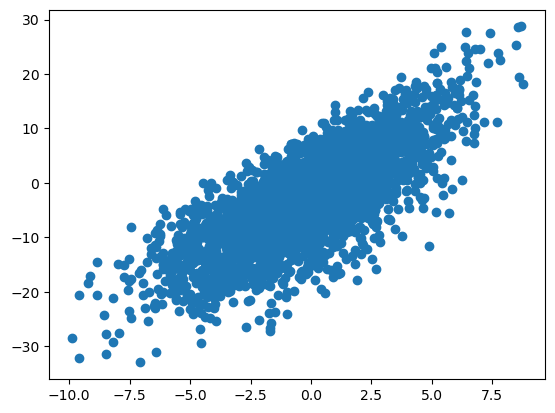

In [224]:
write_trackfile(df_dip, "particles_after_b.txt")

In [ ]:
if os.path.exists("particles_after_bupt.txt"):
    os.remove("particles_after_bupt.txt")
convertZ("particles_after_b.txt",  "particles_after_bupt.txt")

x_params_dip, y_params_dip, z_emit_dip = calc_all_params(df_dip)
D_dict_dip = {"D_x": x_params_dip[4], "D'_x": x_params_dip[5], "D_y": y_params_dip[4], "D'_y": y_params_dip[5]}
b_dict_dip = {"Beta_x": x_params_dip[1], "Beta_y": y_params_dip[1]}
print(D_dict_dip, r"Epsilon_z: "+str(z_emit_dip), b_dict_dip)

In [147]:
df_dip_zero = read_trackfile("particles_after_firstwedgeupt.txt")

In [ ]:
# Sigma cut for phase space -- contribution for the cooling is just 1sigma -- dispersion calculation, useful particles can be in 1 sigma, makes the statement a bit more clear, how do we treat the tail
# 3 sigma cut, 5 sigma cut, dispersion include non-linear tail effect. Increase actual dispersion. In the future we take into account this tail transmission 

In [ ]:
print_all_params(remove_dispersion(post_w1))

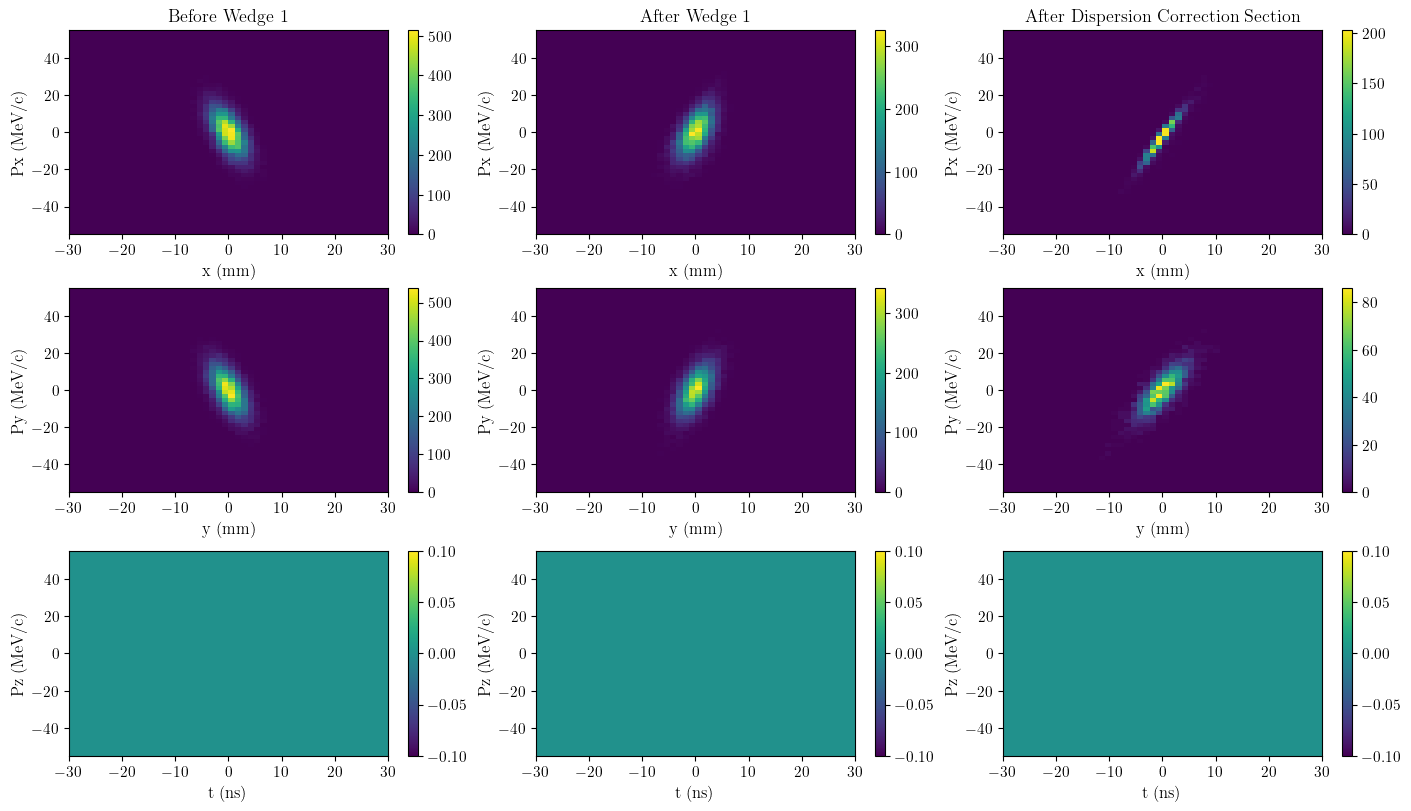

In [98]:
import matplotlib.pyplot as plt

# --- Plot setup ---
PLOT_TARGETS = [pre_w1, post_w1, remove_dispersion(df_dip)]
PLOT_TITLES  = ["Before Wedge 1", "After Wedge 1", "After Dispersion Correction Section"]
PLOT_AXES    = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS  = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
# Histogram ranges: first 2 for T (x,y), last 1 for L (t)
HIST_RANGES  = [[-30, 30, -55, 55], [-30, 30, -55, 55], [-30, 30, -55, 55]]

# LaTeX-friendly fonts
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

fig, axes = plt.subplots(nrows=len(PLOT_AXES), ncols=len(PLOT_TARGETS), figsize=(14, 8), layout="constrained")

for col, df in enumerate(PLOT_TARGETS):
    axes[0][col].set_title(PLOT_TITLES[col], fontsize=13)
    for row, ((xvar, yvar), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[row][col]
        # Select ranges: last row has different ranges
        if row == 2:
            xlim, ylim = HIST_RANGES[col][0:2], HIST_RANGES[col][2:4]
        else:
            xlim, ylim = HIST_RANGES[col][0:2], HIST_RANGES[col][2:4]
        h = ax.hist2d(df[xvar], df[yvar], bins=50, range=[xlim, ylim], cmap="viridis")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        fig.colorbar(h[3], ax=ax, orientation='vertical', fraction=0.045, pad=0.04)

plt.show()

In [36]:
df_dip_zero = read_trackfile("particles_after_bupt.txt")

In [ ]:
with open("particles_after_bupt.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = 2000
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print(trans_percent)

# Phase rotation

The following are taken as constants, as they are primarily constrained by technical limitations. The optimal RF gradient is heavily dependent on both of these.
- **Drift length**: Longer drift length will give better results
- **RF frequency**: Lower frequency will usually give better results. There's an optimal point, but I believe it's lower than practical

We then optimize the RF phase, cavity length, and gradient

In [ ]:
print_all_params(remove_dispersion(post_w1))
print_all_params(df_dip)

In [38]:
no_transverse = remove_transverse(df_dip)

# Reverse transverse momentums in saved copy
reverse_transverse = df_dip.copy(deep=True)
reverse_transverse["Px"] *= -1
reverse_transverse["Py"] *= -1

In [ ]:
drift_length = 16000
rf_freq = 0.025

start = time.time()
# Function to optimize
def func(x):
    rf_phase, rf_length, rf_grad = x
    drift_to_start = drift_length-rf_length/2
    post_drift = recenter_t(z_prop(no_transverse, drift_to_start))
    post_cavity = run_g4beam(post_drift, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad, nparticles=len(no_transverse))
    pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
    return np.std(p_total(cut_pz(pre_w2)))

# Run optimization
optim_result = minimize(func, [0, 4700, 7], method="Nelder-Mead", bounds=((-90, 90), (2000, 6000), (1, 10)), options=dict(fatol=1e-6))

# Get results
rf_phase, rf_length, rf_grad = optim_result.x
print(f"Phase = {rf_phase:.2f} deg\nLength = {rf_length:.0f} mm\nGradient = {rf_grad:.2f} MV/m\nFrequency = {rf_freq*1000:.1f} MHz")
print("Time spent:", time.time()-start)

# Runs a single case with the optimal parameters and add the transverse back in
drift_to_start = drift_length-rf_length/2
post_drift = recenter_t(z_prop(no_transverse, drift_to_start))
post_cavity = cut_pz(recenter_t(run_g4beam(post_drift, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad)))
pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
print_all_params(pre_w2)

In [41]:
write_trackfile(pre_w2, "particles_after_driftph.txt")

In [ ]:
with open("particles_after_driftph.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = 2000
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print(trans_percent)

# Second wedge

Optimize the second wedge in the same way as the first

In [ ]:
# Function to optimize
def func(x):
    length, angle = x
    return emittances(cut_outliers(run_distribution(pre_w2, length, angle, vd_dist, axis=1)))[1]

# Run optimization
optim_result = minimize(func, [5.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=1e-6))

# Get results
w2_length, w2_angle = optim_result.x
print(f"Length = {w2_length:.2f} mm\nAngle = {w2_angle:.1f} deg")

# Runs a single case with the optimal parameters
post_w2 = run_distribution(pre_w2, w2_length, w2_angle, vd_dist, axis=1)
print_all_params(post_w2)

# Do cuts at this point
post_w2_cut = cut_outliers(post_w2)
print_all_params(post_w2_cut)

# Save/load result

In [33]:
# Parameter list
PARAMS = [
    "t_emit",
    "momentum",
    "beta",
    "alpha",
    "l_emit",
    "pz_std",
    "vd_dist",
    "w1_length",
    "w1_angle",
    "w2_length",
    "w2_angle",
    "drift_length",
    "rf_freq",
    "rf_phase",
    "rf_length",
    "rf_grad"
]

In [ ]:
# Show parameters
{k:globals()[k] for k in PARAMS}

In [8]:
# Input parameters
parameters = {'t_emit': 0.145,
 'momentum': 100,
 'beta': 0.03,
 'alpha': 1,
 'l_emit': 1,
 'pz_std': 1,
 'vd_dist': 24,
 'w1_length': 9.20751061747799,
 'w1_angle': 49.78231333988419,
 'w2_length': 6.724887901827298,
 'w2_angle': 42.245718529695516,
 'drift_length': 16000,
 'rf_freq': 0.025,
 'rf_phase': 0.001987066319906211,
 'rf_length': 5153.756925848655,
 'rf_grad': 4.046563465382562}
globals().update(parameters)

In [ ]:
# Save parameter set
parameters = {k:globals()[k] for k in PARAMS}
filename = "results/parameters/"+input("Enter run name to save: ")+".pkl"
with open(filename, "wb+") as file:
    pickle.dump(parameters, file)
    print("Saved to", filename)

In [ ]:
# Load parameter set
filename = "results/parameters/"+input("Enter run name to load: ")+".pkl"
with open(filename, "rb+") as file:
    parameters = pickle.load(file)
    globals().update(parameters)
    print("Loaded from", filename)

In [ ]:
# View parameter set
filename = "results/parameters/"+input("Enter run name to view: ")+".pkl"
with open(filename, "rb+") as file:
    parameters = pickle.load(file)
    print("Viewing", filename)
    print(parameters)

In [255]:
vd_dist=36

# Analyze single case

In [ ]:
# Tweak parameters
rf_phase += 180
rf_phase

In [ ]:
# Run best case
pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=100000)
pre_w1["PDGid"] = -13
print("Running first wedge")
post_w1 = run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0)
post_correct = remove_dispersion(post_w1)
reverse_transverse = post_correct.copy(deep=True)
reverse_transverse["Px"] *= -1
reverse_transverse["Py"] *= -1
drift_to_start = drift_length-rf_length/2
post_drift = recenter_t(z_prop(post_correct, drift_to_start))
no_transverse = remove_transverse(post_drift)
print("Running RF cavity")
post_cavity = cut_pz(recenter_t(run_g4beam(no_transverse, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad, nparticles=len(no_transverse))), tails=0.15)
pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
print("Running second wedge")
post_w2 = run_distribution(pre_w2, w2_length, w2_angle, vd_dist, axis=1)
post_w2_cut = recenter_t(cut_outliers(post_w2))
print_all_params(post_w2_cut)
beep()

In [ ]:
# Make some phase space plots
PLOT_TARGETS = [pre_w1, post_correct, post_drift, pre_w2, remove_dispersion(post_w2_cut)]
PLOT_TITLES = ["Initial distribution", "After first wedge", "After drift", "After RF cavity and refocusing", "After second wedge"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-7.5, 7.5], [-30, 30]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(16, 8)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
# fig.suptitle(f"temit={t_emit*1000:.0f} μm, σP={pz_std:.2f} MeV/c")

In [ ]:
SAMPLE_DISTS = [pre_w1, post_correct, pre_w2, remove_dispersion(post_w2_cut)]
SAMPLE_TITLES = ["Initial distribution", "After first wedge", "After RF cavity + 10% cut", "After second wedge + 4 sigma cut"]
VARIABLE_NAMES = ["x emit (μm)", "y emit (μm)", "z-emit (mm)", "sigma-p (MeV/c)", "sigma-t (ns)", "Beam remaining"]
VARIABLE_FUNCS = [
    lambda df: emittances(df)[0]*1000,
    lambda df: emittances(df)[1]*1000,
    lambda df: emittances(df)[2],
    lambda df: np.std(p_total(df)),
    lambda df: np.std(df["t"]),
    lambda df: len(df) / len(pre_w1)
]
table = [[n] + [y(x) for y in VARIABLE_FUNCS] for n, x in zip(SAMPLE_TITLES, SAMPLE_DISTS)]
print(tabulate(
    table,
    headers=["Stage"] + VARIABLE_NAMES,
    # tablefmt="latex_raw",
    floatfmt=(None, ".1f", ".1f", ".3f", ".3f", ".3f", ".1%")
))

## Anomaly investigation

This is going insane

In [ ]:
momentum = 100
pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
pre_w1["PDGid"] = -13
run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0, debug=True)

In [ ]:
momentums = list(range(50, 101, 10))
results = list() #  Yeah we're back to the old days now
for momentum in tqdm(momentums):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    pre_w1["PDGid"] = -13
    results.append(run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 3, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 12)
for momentum, x, ax in zip(momentums, results, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
pass

In [ ]:
results[0]["PDGid"]

In [ ]:
angles = [30, 40, 50, 60]
momentum = 70
results1 = list() #  Yeah we're back to the old days now
for angle in tqdm(angles):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    results1.append(run_distribution(pre_w1, w1_length, angle, vd_dist, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 2, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 8)
for angle, x, ax in zip(angles, results1, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
    ax.set_title(f"{angle} deg")
pass

In [ ]:
lengths = [3, 6, 9, 12]
momentum = 70
results2 = list() #  Yeah we're back to the old days now
for length in tqdm(lengths):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    results2.append(run_distribution(pre_w1, length, w1_angle, 40, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 2, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 8)
for length, x, ax in zip(lengths, results2, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
    ax.set_title(f"{length} mm")
pass

In [ ]:
fig, ax = plt.subplots()
ax.hist(p_total(post_w2_cut), bins=200)
select_bottom, select_top = 60.5, 62.5
ax.axvline(select_bottom, color="r", linestyle="--")
ax.axvline(select_top, color="r", linestyle="--")
anomaly = post_w2_cut[(p_total(post_w2_cut) < select_top) & (p_total(post_w2_cut) > select_bottom)]
pre_anomaly = pre_w2.loc[anomaly["EventID"]]
post_anomaly = run_distribution(pre_anomaly, w2_length, w2_angle, vd_dist, axis=1)

In [ ]:
# Show the anomaly
PLOT_TARGETS = [pre_w2, pre_anomaly, post_w2_cut, post_anomaly]
PLOT_TITLES = ["Before (full)", "Before (anomalous)", "After (full)", "After (anomalous)"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-7.5, 7.5], [-30, 30]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(10, 8)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
# fig.suptitle(f"temit={t_emit*1000:.0f} μm, σP={pz_std:.2f} MeV/c")

In [ ]:
run_distribution(pre_w1, w2_length, w2_angle, vd_dist, axis=1, debug=True)

In [ ]:
fig, ax = plt.subplots()
ax.hist(post_w2_cut["y"], bins=200)
pass

In [ ]:
p_ranges = [(58.5+2*i, 60.5+2*i) for i in range(7)]

fig, axes = plt.subplots(ncols = 2, nrows = len(p_ranges), layout="constrained")
fig.set_size_inches(6, 3*len(p_ranges))
for i, r in enumerate(p_ranges):
    ax = axes[i][0]
    ax.hist(p_total(post_w2_cut), bins=200, range=(55, 90))
    select_bottom, select_top = r
    ax.axvline(select_bottom, color="r", linestyle="--")
    ax.axvline(select_top, color="r", linestyle="--")

    selected = post_w2_cut[(p_total(post_w2_cut) < select_top) & (p_total(post_w2_cut) > select_bottom)]
    pre_selected = pre_w2.loc[selected["EventID"]]

    ax = axes[i][1]
    ax.hist2d(pre_selected["y"], pre_selected["Py"], bins=50, range=T_RANGES)
    ax.set_xlabel("y")
    ax.set_ylabel("Py")

## Two optimal wedges (regenerated)

In [35]:
# Range to scan
angles = np.linspace(30, 60, 20)
lengths = np.linspace(5, 11, 20)

In [ ]:
def fun(length, angle):
    return run_distribution(pre_w2, length, angle, 24, axis=1)

results = run_scan(fun, (lengths, angles), filename="results/second_wedge_length_angle.pkl")
beep()

In [ ]:
def fun(length, angle):
    return run_distribution(pre_w1, length, angle, 24, axis=0)

results = run_scan(fun, (lengths, angles), filename="results/first_wedge_length_angle.pkl")
beep()

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, layout="constrained")
fig.set_size_inches(10, 4)

# First wedge

with open("results/first_wedge_length_angle.pkl", "rb") as file:
    results = pickle.load(file)

mesh = np.meshgrid(lengths, angles)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: emittances(cut_outliers(df))[0], results))
meshx, meshy = mesh

cax = ax1.contourf(meshx, meshy, meshz, levels=50)
ax1.set_xlabel("First wedge length (mm)")
ax1.set_ylabel("First wedge half-angle (deg)")
ax1.set_title("First wedge")
plt.colorbar(cax, ax=ax1).set_label("x-emittance (mm)")

ax1.plot(w1_length, w1_angle, 'rx')
ax1.annotate(f"{w1_length:.2f} mm, {w1_angle:.2f} deg", (w1_length, w1_angle), c="red", xytext = (-30, 10), textcoords="offset points")

# Second wedge

with open("results/second_wedge_length_angle.pkl", "rb") as file:
    results = pickle.load(file)

mesh = np.meshgrid(lengths, angles)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: emittances(cut_outliers(df))[1], results))
meshx, meshy = mesh

cax = ax2.contourf(meshx, meshy, meshz, levels=50)
ax2.set_xlabel("Second wedge length (mm)")
ax2.set_ylabel("Second wedge half-angle (deg)")
ax2.set_title("Second wedge")
plt.colorbar(cax, ax=ax2).set_label("y-emittance (mm)")

ax2.plot(w2_length, w2_angle, 'rx')
ax2.annotate(f"{w2_length:.2f} mm, {w2_angle:.2f} deg", (w2_length, w2_angle), c="red", xytext = (-30, 10), textcoords="offset points")

## Frequency and gradient (regenerated)

In [90]:
rf_freqs = np.linspace(0.01, 0.06, 20)
rf_grads = np.linspace(1,10,20)

In [ ]:
# get no_transverse from above

def fun(rf_grad, rf_freq):
    return recenter_t(run_g4beam(no_transverse, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad))

results = run_scan(fun, (rf_grads, rf_freqs), "results/rf_grad_freq_16m.pkl")

In [ ]:
with open("results/rf_grad_freq_16m.pkl", "rb") as file:
    results = pickle.load(file)
mesh = np.meshgrid(rf_grads, rf_freqs)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: np.std(cut_pz(df)["Pz"]), results))
meshx, meshy = mesh

meshy = 1000 * meshy # Scale to MHz

fig, ax = plt.subplots()
cax = ax.contourf(meshx, meshy, meshz, levels=50)
ax.set_xlabel("RF gradient (MV/m)")
ax.set_ylabel("RF frequency (MHz)")
plt.colorbar(cax).set_label("sigma-Pz (MeV/c)")

minpoint = np.unravel_index(np.argmin(meshz), meshz.shape)
ax.plot(rf_grad, rf_freq*1000, 'rx')
ax.annotate(f"{rf_grad:.2f} MV/m, {rf_freq*1000:.1f} MHz", (rf_grad, rf_freq*1000), c="red", xytext = (-30, 10), textcoords="offset points")

# Scan of optimal over pz_std

In [18]:
t_emit = 0.110  # mm
momentum = 100  # MeV/c
beta = 0.03    # m
alpha = 1     # dimensionless
l_emit = 1      # mm
pz_stds = np.linspace(0.8, 1.1, 6)
vd_dist = 24    # mm

In [ ]:
# Meta-function (containing optimization)
def metafun(pz_std):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    
    def func(x):
        length, angle = x
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [7.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=2e-4))

run_scan(metafun, (pz_stds,), filename="results/optimal_scan.pkl", trials=5)

In [ ]:
with open("results/optimal_scan.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]


fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 4)
ax1.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"$\sigma p$ (MeV/c)")
ax1.set_ylabel("minimum x emit (mm)")

ax2.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"$\sigma p$ (MeV/c)")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"$\sigma p$ (MeV/c)")
ax3.set_ylabel("optimal half-angle (deg)")

In [ ]:
calc_quantity(optim_fun, results)

In [ ]:
1e-5

In [ ]:
calc_quantity(optim_fun, results)[(0.8,)][1] / 1e-4